<a href="https://colab.research.google.com/github/Moharram-Khaled/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Google Search Ranking & Discoverability Capstone

## Ranking Signal Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Moharram-Khaled/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Ranking Signal Analysis for Content Action Prioritization

A decision-support analysis for identifying content pages that may warrant ranking and optimization review.

## Abstract

This project asks whether observable search-performance signals can support the prioritization of content pages for ranking review. Using FlyRank internship warehouse data, I built a baseline using search visibility and average search position, then compared it with a Logistic Regression model under both random and client-grouped validation. The grouped validation produced an accuracy of 0.7675, compared with 0.6892 for the random split, while F1 decreased from 0.3870 to 0.3191, showing that validation design materially affects the measured result. The analysis suggests that search-performance signals can provide directional decision support, but they are not sufficient to justify automatic content actions. The final output is therefore a ranked review queue with human-review requirements and explicit limitations.

## 1. Introduction / Problem Statement

Content teams often have more pages to review than they can manually investigate. The practical problem is deciding which pages should receive attention first.

This study explores whether observable search-performance signals can provide useful decision-support for prioritizing content pages for ranking review.

The goal is not to prove that a particular optimization will improve rankings. Instead, the goal is to build and validate a transparent workflow that ranks pages for human investigation while making its limitations explicit.

### Case-study framing

This project addresses a content-ranking decision problem: how to prioritize content pages that may deserve further ranking review. The analysis uses observable search-performance signals to create a decision-support workflow rather than an automatic optimization system.

The case study focuses on identifying pages with meaningful search visibility and relatively weak average position, then validating whether these signals can support a useful prioritization baseline. The resulting model and action playbook are intended to help reviewers focus their attention on potentially valuable pages while keeping human review in the loop.



### Research Question

Can observable search-performance signals help prioritize content pages for ranking review?

### Decision Supported

The analysis aims to support a human-reviewed content prioritization workflow. It identifies pages that may deserve additional ranking investigation based on observable historical search signals.

The goal is not to infer Google's ranking algorithm or automatically recommend content changes. The output is intended as directional decision support for prioritizing review.

## 2. Data

This project uses the FlyRank ML Internship dataset and focuses on the content daily performance table.

The analysis uses client and content identifiers in hashed form and does not expose client names, domains, URLs, or private search queries.

The main observed fields used in the analysis are:

- `client_hash_id`
- `content_hash_id`
- `report_date`
- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`

The modeling workflow uses historical observations to construct features and a later observation window to define the movement outcome.

The March 2026 slice was used for the initial baseline analysis. The modeling analysis additionally uses a later outcome window so that the target represents future movement rather than the same-period feature values.

## Label Definition

The modeling target represents whether the page's future average position improved relative to the historical observation window.

The target is binary:

- `1` = future average position improved
- `0` = future average position did not improve

The future outcome is used only as the label and is excluded from the feature set.

## 3. Methodology

### Unit of analysis

The unit of analysis is one content page for one client, represented by a daily observation in the performance table. For modeling, observations were aggregated into a page-client feature representation for the decision window.

### Target

The target is a binary future movement proxy:

- `1` = future average position improved
- `0` = future average position did not improve

The target is used as a directional proxy rather than a causal measure of optimization success.

### Features

The model uses observable signals from the decision window:

- GSC impressions
- GSC average position
- GSC clicks

No future outcome fields are used as model features.

### Baseline

The Week-4 baseline ranks pages using a simple action score combining percentile-ranked impressions and average position.

The baseline is intentionally transparent and serves as the benchmark for the modeling work.

### Model

A Logistic Regression model was selected because the target is binary and the model provides a simple, interpretable benchmark without unnecessary complexity.

### Validation

Two validation designs were compared:

1. Random train/test split.
2. Client-grouped split, where no client appears in both training and test sets.

The grouped split provides a stricter test of generalization to unseen clients.

### Leakage checks

Feature columns were compared against target-derived fields, and client overlap between the grouped training and test sets was checked. The grouped split had zero client overlap.

## 4. Results (vs baseline)

The model was evaluated against a simple baseline using the same evaluation framework.

| Method | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Majority baseline | 0.578 | 0.000 | 0.000 | 0.000 |
| Logistic Regression | 0.637 | 0.650 | 0.302 | 0.413 |

The Week-6 validation audit then compared a random split with a client-grouped split:

| Validation design | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Random split | 0.689 | 0.630 | 0.279 | 0.387 |
| Grouped by client | 0.768 | 0.443 | 0.249 | 0.319 |

The grouped split contained 34 training clients and 12 test clients, with zero client overlap.

The decrease in F1 from 0.387 to 0.319 indicates that performance is more difficult to maintain when evaluating on unseen clients. Therefore, the grouped result is the more conservative estimate for generalization across clients.

### Error analysis

The validation analysis produced 1,592 false positives and 3,810 false negatives.

False positives represent pages predicted to improve that did not improve in the future window. False negatives represent pages that improved but were not identified by the model.

The examples show that search visibility and average position do not capture every factor associated with future ranking movement. Some pages with substantial impressions still moved in the wrong direction, while some pages with relatively weak signals improved.

These errors support treating the model as directional decision-support rather than as an automatic ranking predictor.

## Validation Design

Two validation designs were compared.

The first used a random train/test split. The second used a client-grouped split, ensuring that no client appeared in both training and test sets.

The grouped split contained 34 training clients and 12 test clients, with zero client overlap.

The grouped design provides a stricter test of whether the model generalizes to previously unseen clients.

## 5. Limitations

This analysis has several limitations.

First, the target is a future position-movement proxy rather than a direct measure of the success of a content optimization intervention.

Second, performance varies depending on validation design. The grouped client split produced a lower F1 score than the random split.

Third, GSC and GA4 availability is not uniform across all observations, which can create incomplete feature coverage.

Fourth, the available signals do not capture every factor that may influence search performance, including query-level intent and other contextual information.

Finally, the analysis is observational. It does not establish that changing or refreshing content causes ranking improvement.

The results should therefore be described as observed, measured, directional, and useful for decision-support rather than as causal or production-grade predictions.


## 6. Ranked Recommendations

The action playbook converts the observed signals into a ranked review queue.

### 1. Review high-visibility pages with weaker positions

Reason code: `high_visibility_low_position`

Action: `review_ranking_opportunity`

These pages should receive human review because they have meaningful search exposure but may have room for ranking improvement.

### 2. Check search intent before changing content

A high action score does not prove that content should be rewritten. Reviewers should confirm that the queries generating visibility are relevant to the page.

### 3. Consider freshness as context

Older content may warrant review for potential decay or staleness, but freshness should not automatically trigger a content refresh.

### 4. Prioritize evidence quality

Pages with incomplete data should receive additional investigation before expensive content work.

### 5. Keep humans in the loop

The score should prioritize review rather than automatically publish, rewrite, redirect, or remove content.

## 7. Artifacts the paper embeds

### No-go cases

The following actions should not be automated based only on the model or baseline score:

- Publishing rewritten content.
- Changing search intent.
- Removing or redirecting pages.
- Automatically changing titles or headings.
- Automatically applying internal-link changes.
- Treating a prediction as proof of ranking improvement.
- Making decisions from incomplete data without human review.



## Reproducibility

The analysis was developed as a sequence of notebooks covering:

- ML task framing
- Data contract
- Baseline action scoring
- Capstone modeling
- Validation and research-claim audit
- Content action playbook

The complete work is available in the project repository, including the executed notebooks and generated analysis artifacts.

The paper is intended to remain reproducible from the public repository without exposing private client information.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: [FlyRank](https://flyrank.ai)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Validation": [
        "Random split",
        "Client-grouped split"
    ],
    "Accuracy": [
        0.689212,
        0.767506
    ],
    "F1": [
        0.387023,
        0.319133
    ]
})

display(results)

,Validation,Accuracy,F1
0,Random split,0.689212,0.387023
1,Client-grouped split,0.767506,0.319133


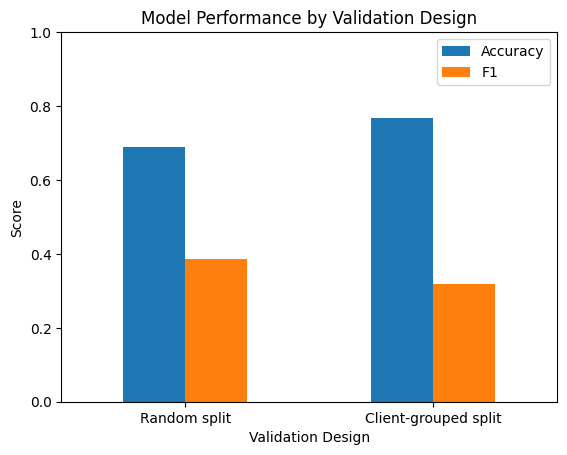

In [8]:
results_plot = results.set_index("Validation")[["Accuracy", "F1"]]

results_plot.plot(kind="bar")

plt.title("Model Performance by Validation Design")
plt.ylabel("Score")
plt.xlabel("Validation Design")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


# 5-Minute Demo Outline

## 1. Question — 45 seconds

Can observable search-performance signals help prioritize content pages for ranking review?

The goal is not to automate content decisions, but to create a practical decision-support workflow that helps reviewers focus on potentially valuable pages.

## 2. Method — 1 minute

I used content-level search-performance observations from the FlyRank internship warehouse.

The baseline focused on:
- GSC impressions
- GSC average position

I then built a Logistic Regression model using historical search signals and evaluated it using both a random split and a client-grouped split to test whether performance remained stable when clients were unseen.

## 3. One Chart — 1 minute

Show the model-versus-baseline validation chart.

The chart compares:
- Random split
- Client-grouped split

using the same evaluation metrics.

## 4. One Honest Result — 1 minute

The random split achieved 0.6892 accuracy and 0.3870 F1.

The grouped-by-client split achieved 0.7675 accuracy but a lower F1 of 0.3191.

This shows that accuracy alone does not tell the full story and that validation design changes the measured result.

## 5. Recommendation — 1 minute

Use the output as a ranked review queue rather than an automatic content-action system.

Pages with meaningful search visibility and relatively weak average position can be prioritized for human review, but reviewers should check search intent, data completeness, query quality, and whether the page is already improving before taking action.

# Shareable Cuts

## Short Social Post

I built a search-intelligence workflow using FlyRank internship warehouse data to explore how content pages can be prioritized for ranking review.

I started with a simple baseline using GSC impressions and average position, then tested a Logistic Regression model under random and client-grouped validation. The results showed why validation design matters: the grouped split changed the measured performance and reduced F1 compared with the random split.

The final output is a ranked, human-reviewed action queue rather than an automated content recommendation system.

## Employer-Facing Summary

I built a machine-learning workflow for ranking-opportunity prioritization using FlyRank internship warehouse data and historical search-performance signals. I created a baseline, trained a Logistic Regression model, compared random and client-grouped validation, and audited the model for leakage and failure cases. The results showed that validation design materially affects measured performance, leading me to frame the final system as decision-support with human review rather than automatic content optimization.